# Vision Transformer с нуля на PyTorch

В этой работе нужно реализовать основные части Vision Transformer (ViT): разбиение изображения на патчи, patch embedding, positional embeddings, multi-head self-attention, transformer encoder block и итоговую модель классификации.

**Цель:** понять, как изображение превращается в последовательность токенов и как Transformer применяют к задаче классификации изображений.

## Правила

- Нельзя использовать готовую реализацию ViT из `timm`, `torchvision.models`, HuggingFace и подобных библиотек.
- Можно использовать PyTorch, torchvision datasets/transforms, matplotlib, numpy.
- В основных заданиях attention нужно реализовать вручную.


# 0. Установка и импорты

Если вы работаете в Google Colab, обычно достаточно установить только `torchvision`, если он не установлен.


In [2]:
import math
import random
from dataclasses import dataclass
from typing import Tuple, Optional, Dict, List

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

try:
    import torchvision
    import torchvision.transforms as T
except Exception as e:
    torchvision = None
    T = None
    print("torchvision is not available:", e)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


In [3]:
import torch
print(torch.cuda.is_available())  # должно быть True
print(torch.cuda.get_device_name(0))  # NVIDIA GeForce RTX 4060

True
NVIDIA GeForce RTX 4060 Laptop GPU


# 1. Идея ViT

Обычная CNN обрабатывает изображение локальными свёртками. Vision Transformer делает иначе:

1. Делит изображение на маленькие квадратные патчи.
2. Каждый патч превращает в вектор — токен.
3. Добавляет positional embedding, чтобы модель знала порядок патчей.
4. Пропускает последовательность токенов через Transformer Encoder.
5. Использует специальный `[CLS]` токен для классификации.

Для изображения размера `H x W` и patch size `P` количество патчей:

$$N = 
{H}/{P} \cdot
{W}/{P}$$

Если изображение CIFAR10 имеет размер `32 x 32`, а patch size равен `4`, то получится `8 x 8 = 64` патча.

# Теоретический вопрос 1 

1. Зачем нужен токен CLS?
2. В чем идея деления пространства признаков на "головы внимания"?
3. На чем основывается выбор размера патча? 

## Ваш ответ:

1. CLS токен - это специальный обучаемый вектор, который добавляется к последовательности патчей перед подачей в Transformer Encoder. Он не соответствует никакому патчу изображения, но через механизм self-attention собирает информацию со всех остальных токенов

2. Multi-head attention делит пространство признаков на `num_heads` независимых подпространств. Каждая голова обучается обращать внимание на разные аспекты входа. 

3. Выбор размера патча - выбор между:
- Вычислительной стоимостью: меньший патч, больше токенов N, сложность attention O(N²) растёт квадратично.
- Детальностью информации: меньший патч, каждый токен несёт меньше пикселей, лучше локальная детализация.
- Способностью обобщать: очень маленькие патчи дают много шума и требуют больше данных.
Для CIFAR-10 (32×32) стандартный выбор — P=4, что даёт 64 токена; для ImageNet (224×224) — P=16, что даёт 196 токенов.


# 2. Разбиение изображения на патчи

Реализуйте функцию `image_to_patches`.

In [4]:
def image_to_patches(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """
    Convert batch of images into a batch of flattened patches.

    Args:
        x: Tensor of shape [B, C, H, W]
        patch_size: int, patch size P

    Returns:
        patches: Tensor of shape [B, N, C * P * P]
    """
    B, C, H, W = x.shape
    assert H % patch_size == 0 and W % patch_size == 0, \
        f"Image size ({H}x{W}) must be divisible by patch_size ({patch_size})"
    h_p = H // patch_size
    w_p = W // patch_size
    # [B, C, h_p, P, w_p, P]
    x = x.reshape(B, C, h_p, patch_size, w_p, patch_size)
    # [B, h_p, w_p, C, P, P]
    x = x.permute(0, 2, 4, 1, 3, 5)
    # [B, N, C*P*P]
    x = x.reshape(B, h_p * w_p, C * patch_size * patch_size)
    return x


In [5]:
# Тесты для image_to_patches
x_test = torch.arange(2 * 3 * 8 * 8).float().reshape(2, 3, 8, 8)
patches = image_to_patches(x_test, patch_size=4)
assert patches.shape == (2, 4, 3 * 4 * 4), patches.shape
manual_first_patch = x_test[0, :, 0:4, 0:4].reshape(-1)
assert torch.equal(patches[0, 0], manual_first_patch)
print("image_to_patches tests passed")


image_to_patches tests passed


# 3. Patch Embedding

Далее патчи преобразуем в эмбеддинги длиной embed_dim в `PatchEmbedding`:

`[B, C, H, W] -> [B, N, embed_dim]`


In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size: int, patch_size: int, in_channels: int, embed_dim: int):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.image_size = image_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = in_channels * patch_size * patch_size

        self.proj = nn.Linear(self.patch_dim, embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        patches = image_to_patches(x, self.patch_size)   # [B, N, patch_dim]
        tokens = self.proj(patches)                        # [B, N, embed_dim]
        return tokens


In [7]:
# Тесты для PatchEmbedding
patch_embed = PatchEmbedding(image_size=32, patch_size=4, in_channels=3, embed_dim=64)
x = torch.randn(5, 3, 32, 32)
out = patch_embed(x)
assert out.shape == (5, 64, 64), out.shape
assert patch_embed.num_patches == 64
print("PatchEmbedding tests passed")


PatchEmbedding tests passed


# 4. Positional Embeddings и CLS token

Transformer сам по себе не знает порядок токенов. Поэтому к токенам добавляют positional embeddings.

Для классификации часто добавляют специальный `[CLS]` токен. После Transformer Encoder берут именно его выход и подают в классификатор.

Реализуйте класс `TokenPreparation`:

```python
patch_tokens: [B, N, D]
output:       [B, N + 1, D]
```


In [8]:
class TokenPreparation(nn.Module):
    def __init__(self, num_patches: int, embed_dim: int):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, patch_tokens: torch.Tensor) -> torch.Tensor:
        B = patch_tokens.shape[0]
        cls = self.cls_token.expand(B, -1, -1)          # [B, 1, D]
        x = torch.cat([cls, patch_tokens], dim=1)        # [B, N+1, D]
        x = x + self.pos_embed                           # добавляем позиционные эмбеддинги
        return x


In [9]:
# Тесты для TokenPreparation
prep = TokenPreparation(num_patches=64, embed_dim=128)
tokens = torch.randn(2, 64, 128)
out = prep(tokens)
assert out.shape == (2, 65, 128), out.shape
assert isinstance(prep.cls_token, nn.Parameter)
assert isinstance(prep.pos_embed, nn.Parameter)
print("TokenPreparation tests passed")


TokenPreparation tests passed


# 5. Scaled Dot-Product Attention

Реализуйте attention:

$$Attention(Q, K, V) = softmax(
{QK^T}/{\sqrt{d_k}}
)V$$

Вход: `q, k, v: [B, heads, N, head_dim]`

Выход:

- `out: [B, heads, N, head_dim]`
- `attn: [B, heads, N, N]`


In [10]:
def scaled_dot_product_attention(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    dropout: Optional[nn.Module] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    head_dim = q.shape[-1]
    # QK^T / sqrt(d_k)  →  [B, heads, N, N]
    scores = q @ k.transpose(-2, -1) / math.sqrt(head_dim)
    attn = F.softmax(scores, dim=-1)
    if dropout is not None:
        attn = dropout(attn)
    out = attn @ v  # [B, heads, N, head_dim]
    return out, attn


In [11]:
# Тесты для scaled_dot_product_attention
q = torch.randn(2, 4, 10, 16)
k = torch.randn(2, 4, 10, 16)
v = torch.randn(2, 4, 10, 16)
out, attn = scaled_dot_product_attention(q, k, v)
assert out.shape == (2, 4, 10, 16)
assert attn.shape == (2, 4, 10, 10)
assert torch.allclose(attn.sum(dim=-1), torch.ones_like(attn.sum(dim=-1)), atol=1e-5)
print("scaled_dot_product_attention tests passed")


scaled_dot_product_attention tests passed


# 6. Multi-Head Self-Attention

Реализуйте `MultiHeadSelfAttention`.

Внутри нужно:

1. Получить `qkv` одной линейной проекцией или тремя отдельными.
2. Разделить embedding dimension на `num_heads` голов.
3. Применить scaled dot-product attention.
4. Склеить головы обратно.
5. Применить финальную линейную проекцию.


In [12]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, attn_dropout: float = 0.0, proj_dropout: float = 0.0):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # Одна матрица для Q, K, V 
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(attn_dropout)
        self.proj_drop = nn.Dropout(proj_dropout)
        self.last_attention: Optional[torch.Tensor] = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, D = x.shape

        qkv = self.qkv(x)                                      # [B, N, 3D]
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)                      # [3, B, heads, N, head_dim]
        q, k, v = qkv.unbind(0)                                # каждый [B, heads, N, head_dim]

        out, attn = scaled_dot_product_attention(q, k, v, dropout=self.attn_drop)
        self.last_attention = attn                             # для визуализации

        # склеиваем головы обратно
        out = out.transpose(1, 2).reshape(B, N, D)            # [B, N, D]
        out = self.proj(out)
        out = self.proj_drop(out)
        return out


In [13]:
# Тесты для MultiHeadSelfAttention
mha = MultiHeadSelfAttention(embed_dim=128, num_heads=8)
x = torch.randn(3, 65, 128)
y = mha(x)
assert y.shape == x.shape
assert mha.last_attention is not None
assert mha.last_attention.shape == (3, 8, 65, 65)
print("MultiHeadSelfAttention tests passed")


MultiHeadSelfAttention tests passed


# 7. MLP block

В Transformer Encoder после attention идёт feed-forward network:

`Linear(D, hidden_dim) -> GELU -> Dropout -> Linear(hidden_dim, D) -> Dropout`


In [14]:
class MLP(nn.Module):
    def __init__(self, embed_dim: int, mlp_ratio: float = 4.0, dropout: float = 0.0):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


In [15]:
# Тесты для MLP
mlp = MLP(embed_dim=128, mlp_ratio=4.0, dropout=0.1)
x = torch.randn(2, 65, 128)
y = mlp(x)
assert y.shape == x.shape
print("MLP tests passed")


MLP tests passed


# 8. Transformer Encoder Block

Реализуйте Pre-LN блок:

```text
x = x + Attention(LayerNorm(x))
x = x + MLP(LayerNorm(x))
```


In [16]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.0, attn_dropout: float = 0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, attn_dropout=attn_dropout, proj_dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio=mlp_ratio, dropout=dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pre-LN: LayerNorm перед attention/MLP + residual connection
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


In [17]:
# Тесты для TransformerEncoderBlock
block = TransformerEncoderBlock(embed_dim=128, num_heads=8, dropout=0.1, attn_dropout=0.1)
x = torch.randn(2, 65, 128)
y = block(x)
assert y.shape == x.shape
print("TransformerEncoderBlock tests passed")


TransformerEncoderBlock tests passed


# 9. Полная модель Vision Transformer

Соберите полный ViT:

1. PatchEmbedding
2. TokenPreparation
3. Несколько TransformerEncoderBlock
4. LayerNorm
5. Classification head


In [18]:
@dataclass
class ViTConfig:
    image_size: int = 32
    patch_size: int = 4
    in_channels: int = 3
    num_classes: int = 10
    embed_dim: int = 128
    depth: int = 4
    num_heads: int = 8
    mlp_ratio: float = 4.0
    dropout: float = 0.1
    attn_dropout: float = 0.1


class VisionTransformer(nn.Module):
    def __init__(self, config: ViTConfig):
        super().__init__()
        self.config = config

        self.patch_embed = PatchEmbedding(
            config.image_size, config.patch_size, config.in_channels, config.embed_dim
        )
        self.token_prep = TokenPreparation(self.patch_embed.num_patches, config.embed_dim)
        self.dropout = nn.Dropout(config.dropout)
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                config.embed_dim, config.num_heads,
                config.mlp_ratio, config.dropout, config.attn_dropout
            )
            for _ in range(config.depth)
        ])
        self.norm = nn.LayerNorm(config.embed_dim)
        self.head = nn.Linear(config.embed_dim, config.num_classes)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)    # [B, N, D]
        x = self.token_prep(x)     # [B, N+1, D]
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        cls_token = x[:, 0]        # берём CLS токен
        return self.head(cls_token) # [B, num_classes]


In [19]:
# Тесты для VisionTransformer
config = ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=2, num_heads=8, num_classes=10)
model = VisionTransformer(config)
x = torch.randn(4, 3, 32, 32)
logits = model(x)
assert logits.shape == (4, 10), logits.shape
print("VisionTransformer tests passed")


VisionTransformer tests passed


# 10. Данные CIFAR10

In [20]:
def get_cifar10_loaders(batch_size: int = 128, val_size: int = 5000):
    assert torchvision is not None, "torchvision is required for CIFAR10"
    train_transform = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    test_transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    full_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
    test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)
    train_size = len(full_train) - val_size
    train_set, val_set = random_split(full_train, [train_size, val_size])
    # num_workers=0 обязателен на Windows в Jupyter (multiprocessing зависает)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    return train_loader, val_loader, test_loader


# 11. Training loop

Реализуйте функции `train_one_epoch` и `evaluate`.

Требования:

- использовать `model.train()` при обучении;
- использовать `model.eval()` при оценке;
- считать средний loss;
- считать accuracy.


In [21]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion, device: str) -> Dict[str, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        batch_size = x.shape[0]
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size
    return {"loss": total_loss / total_count, "acc": total_correct / total_count}


@torch.no_grad()
def evaluate(model, loader, criterion, device: str) -> Dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        batch_size = x.shape[0]
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += batch_size
    return {"loss": total_loss / total_count, "acc": total_correct / total_count}


In [22]:
# Быстрая проверка training loop на случайных данных
class RandomImageDataset(torch.utils.data.Dataset):
    def __init__(self, n=128, num_classes=10):
        self.x = torch.randn(n, 3, 32, 32)
        self.y = torch.randint(0, num_classes, (n,))
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

random_loader = DataLoader(RandomImageDataset(n=64), batch_size=16, shuffle=True)
model = VisionTransformer(ViTConfig(depth=1, embed_dim=64, num_heads=4)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
train_metrics = train_one_epoch(model, random_loader, optimizer, criterion, DEVICE)
val_metrics = evaluate(model, random_loader, criterion, DEVICE)
assert "loss" in train_metrics and "acc" in train_metrics
assert "loss" in val_metrics and "acc" in val_metrics
print("training loop tests passed", train_metrics, val_metrics)


training loop tests passed {'loss': 2.3372596502304077, 'acc': 0.046875} {'loss': 2.2874695658683777, 'acc': 0.140625}


# 12. Запуск обучения

Рекомендуемые параметры для первого запуска:

```python
ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=8)
```

Для быстрой проверки можно поставить `depth=2`, `embed_dim=64`, `num_heads=4`.

### Validation acc > 0.6 => 100% score


In [23]:
train_loader, val_loader, test_loader = get_cifar10_loaders(batch_size=128)
config = ViTConfig(image_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=8)
model = VisionTransformer(config).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
epochs = 10
for epoch in range(1, epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])
    print(f"Epoch {epoch:02d}: train loss={train_metrics['loss']:.4f}, train acc={train_metrics['acc']:.4f}, val loss={val_metrics['loss']:.4f}, val acc={val_metrics['acc']:.4f}")


c:\Users\User\anaconda3\envs\CV\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch 01: train loss=1.8856, train acc=0.2921, val loss=1.7173, val acc=0.3636
Epoch 02: train loss=1.6401, train acc=0.3890, val loss=1.5172, val acc=0.4466
Epoch 03: train loss=1.4740, train acc=0.4602, val loss=1.3719, val acc=0.5050
Epoch 04: train loss=1.3706, train acc=0.5006, val loss=1.3096, val acc=0.5326
Epoch 05: train loss=1.2930, train acc=0.5322, val loss=1.2297, val acc=0.5454
Epoch 06: train loss=1.2498, train acc=0.5482, val loss=1.1981, val acc=0.5762
Epoch 07: train loss=1.1934, train acc=0.5685, val loss=1.1422, val acc=0.5932
Epoch 08: train loss=1.1615, train acc=0.5791, val loss=1.1100, val acc=0.6056
Epoch 09: train loss=1.1294, train acc=0.5924, val loss=1.0726, val acc=0.6176
Epoch 10: train loss=1.0857, train acc=0.6112, val loss=1.0425, val acc=0.6320


# 13. Графики обучения

Постройте графики loss и accuracy.


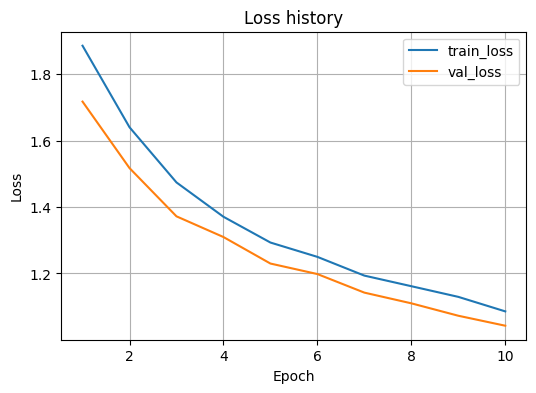

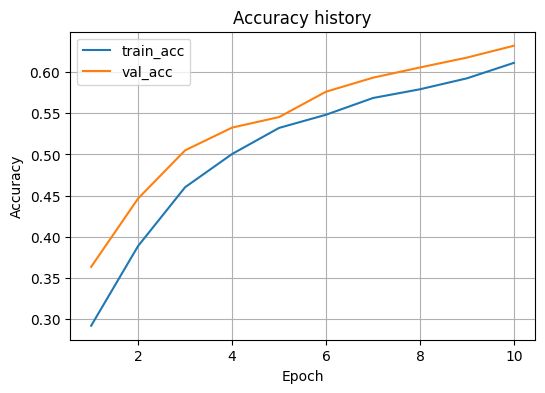

In [24]:
def plot_history(history: Dict[str, List[float]]):
    if not history.get("train_loss"):
        print("History is empty. Train the model first or pass a filled history dictionary.")
        return

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss history")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy history")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)


# 14. Дополнительное задание: визуализация attention

После forward pass в каждом attention-блоке сохранено поле `last_attention`.

Форма: `[B, heads, N + 1, N + 1]`

Для визуализации можно взять attention из CLS token к patch tokens:

```python
attn[0, head_id, 0, 1:]
```

Затем reshape в сетку `sqrt(N) x sqrt(N)`.


In [26]:
def get_last_block_cls_attention(model: VisionTransformer, x: torch.Tensor, head_id: int = 0) -> torch.Tensor:
    model.eval()
    with torch.no_grad():
        model(x)
    attn = model.blocks[-1].attn.last_attention  # [B, heads, N+1, N+1]
    grid_size = int(math.sqrt(attn.shape[-1] - 1))
    cls_attn = attn[0, head_id, 0, 1:]           # [N]
    return cls_attn.reshape(grid_size, grid_size) # [grid, grid]


def visualize_attention_on_image(image: torch.Tensor, attention_map: torch.Tensor):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")
    axes[1].imshow(attention_map.cpu().numpy(), cmap="hot", interpolation="nearest")
    axes[1].set_title("CLS Attention Map")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


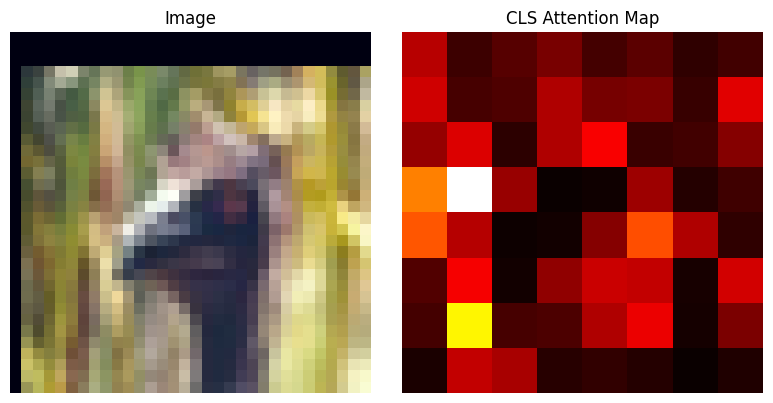

In [27]:
sample_images, sample_labels = next(iter(val_loader))
x_sample = sample_images[:1].to(DEVICE)

attn_map = get_last_block_cls_attention(model, x_sample, head_id=0)
visualize_attention_on_image(sample_images[0], attn_map.cpu())


# 16. Вопросы 2

1. Почему сложность self-attention растёт как `O(N^2)` по числу токенов?
2. Почему ViT обычно требует больше данных, чем CNN?
3. Что произойдёт, если убрать residual connections?
4. Что произойдёт, если убрать LayerNorm?


## Ваш ответ:

1. O(N²) сложность self-attention.
В матрице scores = QK^T каждый из N токенов сравнивается с каждым другим: получается матрица N×N. Её вычисление стоит O(N²·d), где d — размерность головы

2. ViT требует больше данных, чем CNN
CNN обладают встроенными inductive biases:
- Локальность - свёртка смотрит на локальный регион, что отражает природу изображений
- Equivariance к сдвигам — одни и те же веса применяются по всему изображению

ViT не имеет этого: attention равноправно смотрит на все патчи

3. Без residual connections градиент должен проходить через все слои подряд. В глубокой сети это ведёт к тому, что ранние слои обучаются крайне медленно или вообще не обучаются

4. Без LayerNorm активации могут иметь произвольный масштаб после каждого блока. Это дестабилизирует обучение: веса в attention'е и MLP получают очень разные по масштабу входы и градиенты сильно увеличиваются
